<div align="center">
  <img src="imagen_portada.png" alt="imagen_portada.png" width="350"/>
</div>

## ¿Positiva o negativa? Clasificación automática de opiniones con NLP



**Autor:** Diógenes Lugo  
**Programa:** Máster en Ciencia de Datos  
**Institución:** KeepCoding  
**Fecha:** 22-02-2026

## Objetivo del proyecto

El objetivo de este proyecto es desarrollar un modelo supervisado capaz de clasificar automáticamente reseñas de películas y series como positivas o negativas, utilizando técnicas de Procesamiento de Lenguaje Natural (NLP).

Se busca evaluar si el contenido textual de una review contiene suficiente información semántica para predecir el sentimiento del usuario sin necesidad de utilizar explícitamente la puntuación en estrellas como entrada del modelo.

---

## Pregunta principal

**¿Es posible determinar automáticamente si una reseña será positiva o negativa basándonos únicamente en el texto escrito por el usuario?**

Esta capacidad permitiría automatizar el análisis de satisfacción, monitorear la percepción del contenido y generar métricas de opinión en plataformas digitales sin depender exclusivamente de valoraciones numéricas.

---

## Alcance

Este proyecto se centra en:

- La exploración y limpieza del texto libre de las reseñas.
- La transformación del lenguaje natural en variables numéricas aptas para modelado.
- La construcción de una etiqueta binaria (positivo/negativo) basada en la valoración original.
- El entrenamiento y evaluación de modelos supervisados de clasificación.
- El análisis del desempeño del modelo y su capacidad de generalización.
<!--  -->

In [1]:
# =============================================
# Configuración inicial del entorno
# =============================================

# -----------------------------
# Librerías principales
# -----------------------------
import numpy as np
import pandas as pd
import random
import json
from collections import Counter
from wordcloud import WordCloud

# -----------------------------
# Visualización
# -----------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("seaborn-v0_8")
sns.set_context("notebook")

# -----------------------------
# Procesamiento de texto (NLP)
# -----------------------------
import re
import string
import unicodedata

# NLTK
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer, WordNetLemmatizer

#nltk.download("stopwords")  # Descargar solo una vez
#nltk.download("punkt")  # Descargar solo una vez
#nltk.download("wordnet")  # Descargar solo una vez

STOPWORDS_ES = set(stopwords.words("spanish"))
STOPWORDS_EN = set(stopwords.words("english"))

# -----------------------------
# Feature Engineering (Texto)
# -----------------------------
from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)

from sklearn.decomposition import (
    TruncatedSVD,
    PCA
)

# -----------------------------
# Modelado clásico (ML)
# -----------------------------
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# -----------------------------
# Utilidades del sistema
# -----------------------------
import os
import gc
import warnings
warnings.filterwarnings("ignore")

# -----------------------------
# Configuración de dispositivo
# -----------------------------
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "CPU"
print(f"Dispositivo en uso: {DEVICE}")

Dispositivo en uso: CPU


## 1. Análisis principal (EDA)

En esta sección se realiza un **Análisis Exploratorio de Datos (EDA)** para comprender la estructura, distribución y características principales de las reseñas, así como la relación entre el texto y las valoraciones.


In [2]:
file_path = "Movies_and_TV_5_subset.json"

# Leer todo el subset de 100k filas
data = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)

# Ver primeras filas como tabla
df.head(10) 

,overall,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime,vote,image
0,1,False,"10 9, 2012",A3IBNV44XC648X,B004RD37JW,{'Format:': ' Amazon Video'},texadelphia,Don't waste your hard-earned money. This movi...,Terrible Movie,1349740800,None,None
1,5,True,"11 28, 2015",ABITPLKOSQOMO,B00LT1JHLW,{'Format:': ' Blu-ray'},George,Best deal ever,Five Stars,1448668800,2,None
2,3,True,"05 30, 2016",AA6UPTZJ1GXK2,B000TJ6PBU,{'Format:': ' Amazon Video'},Julie Metz,Pretty good scary movie.,Three Stars,1464566400,None,None
3,3,True,"01 4, 2017",A1W5RUAJRI8ZD3,B0013J55B6,{'Format:': ' Amazon Video'},Scott,Funny Movie. I would recommend. Worth renting,Three Stars,1483488000,None,None
4,5,True,"04 12, 2015",A2FT7XIQYANN87,6302718872,{'Format:': ' DVD'},The Trainman,great movie a little off the wall as history g...,great movie a little off the wall as history g...,1428796800,None,None
5,4,True,"04 29, 2018",A3FTZ47MNKO1CI,B00005JLPK,{'Format:': ' Blu-ray'},Mikal C. Johnson,I don't know what I was thinking... a film abo...,Hermosa... but not in Spanish,1524960000,None,None
6,4,False,"07 5, 2015",A2CHH5U12THP2D,B00VNQWUB2,{'Format:': ' DVD'},The Purple Bee,Sound track could be better. Peter Coyote woul...,See It,1436054400,5.0,None
7,4,True,"04 30, 2008",A81P47EIXM8HA,B0012IV3PK,{'Format:': ' DVD'},Richardson,"Hi Folks, I'm not a Yankee or Diamondback supp...",5 star series....3 star DVD collection ..a 4 s...,1209513600,19,None
8,5,True,"02 15, 2016",A3RPLCEFOTTVO6,B00SU2UXUW,{'Format:': ' DVD'},ccc,good show,good showw,1455494400,None,None
9,5,True,"09 11, 2016",A16WAQ8FAC137W,B01G71NN3Q,{'Format:': ' Prime Video'},zoey l. brown,"Like Black Swan, The Witch, Only Lovers Left A...",Buy it.,1473552000,None,None


In [3]:
# nombres de columnas
df.columns

Index(['overall', 'verified', 'reviewTime', 'reviewerID', 'asin', 'style',
       'reviewerName', 'reviewText', 'summary', 'unixReviewTime', 'vote',
       'image'],
      dtype='str')

In [4]:
# info general de tipos y nulos
print(df.info()) 

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   overall         100000 non-null  int64 
 1   verified        100000 non-null  bool  
 2   reviewTime      100000 non-null  str   
 3   reviewerID      100000 non-null  str   
 4   asin            100000 non-null  str   
 5   style           94938 non-null   object
 6   reviewerName    99999 non-null   str   
 7   reviewText      99959 non-null   str   
 8   summary         99979 non-null   str   
 9   unixReviewTime  100000 non-null  int64 
 10  vote            18781 non-null   object
 11  image           198 non-null     object
dtypes: bool(1), int64(2), object(3), str(6)
memory usage: 8.5+ MB
None


## Estrutura del dataset

| Columna          | Tipo (dtype) | Descripción |
|------------------|--------------|------------|
| overall          | int64        | Puntuación otorgada por el usuario a la película o serie (escala de 1 a 5 estrellas). Variable objetivo del proyecto. |
| verified         | bool         | Indica si la review corresponde a una compra verificada. |
| reviewTime       | str          | Fecha en formato texto en la que se realizó la review. |
| reviewerID       | str          | Identificador único del usuario que escribió la review. |
| asin (Amazon Standard Identification Number)            | str          | Identificador de Amazon único del producto (película o serie). |
| style            | object       | Información adicional sobre la versión o formato del producto (por ejemplo, edición o tipo de formato). |
| reviewerName     | str          | Nombre del usuario que escribió la review. |
| reviewText       | str          | Texto completo de la review escrita por el usuario. Principal variable de entrada para el análisis NLP. |
| summary          | str          | Título o resumen breve de la review. |
| unixReviewTime   | int64        | Fecha de la review en formato timestamp (Unix). |
| vote             | object       | Número de votos útiles recibidos por la review (puede requerir limpieza). |
| image            | object       | Imágenes adjuntas a la review. |

---

## Información general del dataset

- **Número de filas:** 100 000  
- **Número de columnas:** 12  
- **Columnas con valores nulos:** style, reviewerName (1 valor nulo), reviewText (algunos valores nulos), summary (algunos valores nulos), vote, image  
- **Columnas numéricas:**  
  - 2 variables int64 (`overall`, `unixReviewTime`)  
- **Columnas booleanas:**  
  - 1 variable bool (`verified`)  
- **Columnas de tipo texto (str / object):**  
  `reviewTime`, `reviewerID`, `asin`, `style`, `reviewerName`, `reviewText`, `summary`, `vote`, `image`


In [5]:
# Columnas de texto y puntuación
if 'reviewText' in df.columns and 'overall' in df.columns:
    print(df[['reviewText', 'overall']].head(10))

                                          reviewText  overall
0  Don't waste your hard-earned money.  This movi...        1
1                                     Best deal ever        5
2                           Pretty good scary movie.        3
3      Funny Movie. I would recommend. Worth renting        3
4  great movie a little off the wall as history g...        5
5  I don't know what I was thinking... a film abo...        4
6  Sound track could be better. Peter Coyote woul...        4
7  Hi Folks, I'm not a Yankee or Diamondback supp...        4
8                                          good show        5
9  Like Black Swan, The Witch, Only Lovers Left A...        5


In [6]:
# Verificar variable objetivo
df['overall'].value_counts()

overall
5    59302
4    19881
3    10076
1     5709
2     5032
Name: count, dtype: int64

In [7]:
# Distribución de compras verificadas
print(df['verified'].value_counts())
print("\nProporción:")
print(df['verified'].value_counts(normalize=True))

verified
True     73581
False    26419
Name: count, dtype: int64

Proporción:
verified
True     0.73581
False    0.26419
Name: proportion, dtype: float64


In [8]:
# Verificar variable vote

# Se convierte todo a string primero
df['vote_clean'] = (
    df['vote']
    .astype(str)                 # aseguramos tipo string
    .str.replace(',', '', regex=False)
    .replace('nan', '0')         # por si NaN se convirtió en texto
)

# Se convierte todo a numérico 
df['vote_clean'] = pd.to_numeric(df['vote_clean'], errors='coerce').fillna(0).astype(int)

print(df['vote_clean'].describe())

# Top reviews más votadas
df[['reviewText', 'vote_clean']].sort_values('vote_clean', ascending=False).head()

count    100000.000000
mean          1.688000
std          15.952954
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        3672.000000
Name: vote_clean, dtype: float64


,reviewText,vote_clean
53500,SKIP THE 2Disc THEATRICAL EDITION -- BUY THE S...,3672
59550,Before I purchased this set I spent some time ...,1100
5670,There are three absolutely gorgeous new transf...,1042
32901,I love the Looney Toons but have been apprehen...,925
14570,My wife and I loved Downton Abbey from the fir...,692


In [9]:
# Verified vs overall
print(df.groupby('verified')['overall'].mean())

# Vote vs overall
print(df.groupby('overall')['vote_clean'].mean())

verified
False    3.872857
True     4.345116
Name: overall, dtype: float64
overall
1    3.105798
2    1.973569
3    1.517269
4    1.854384
5    1.500506
Name: vote_clean, dtype: float64


In [10]:
# Reviewers más activos
active_reviewers = df["reviewerID"].value_counts()
active_reviewers

reviewerID
AV6QDP8Q0ONK4     118
ABO2ZI2Y5DQ9T      70
A328S9RN3U5M68     62
AIMR915K4YCN       62
A1GGOC9PVDXW7Z     55
                 ... 
A3RAL0D6WM42US      1
A3CPX27XQ4BOKX      1
AOJ1KCAZB1T2Y       1
A1F92EK0MUNOVR      1
A1ICNTZI5JSTFJ      1
Name: count, Length: 73226, dtype: int64

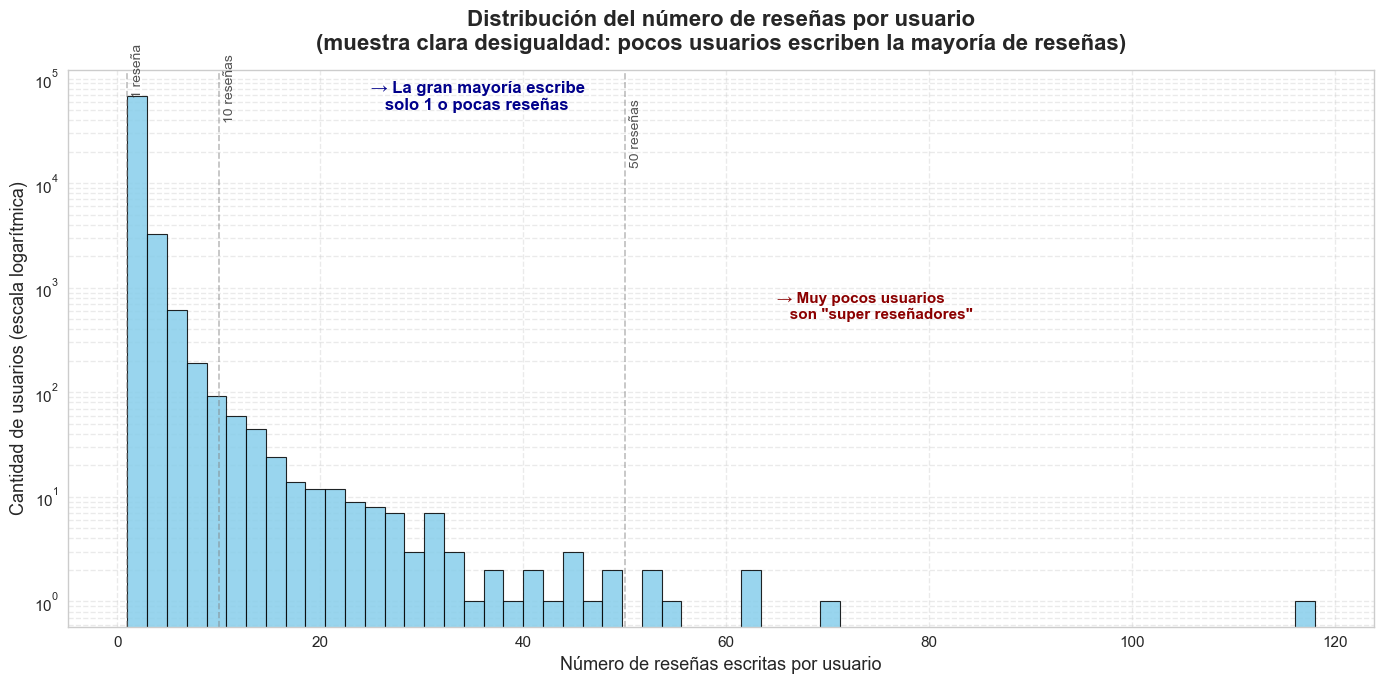

In [11]:
# Distribución de número de reseñas por usuario

# Configuración general
plt.style.use('seaborn-v0_8-whitegrid')   
sns.set_palette("muted")

# Figura del plot
plt.figure(figsize=(14, 7))

# Histograma con escala logarítmica 
plt.hist(active_reviewers, 
         bins=60,               
         log=True,             
         color='skyblue', 
         edgecolor='black', 
         linewidth=0.8,
         alpha=0.85)

# Títulos y etiquetas 
plt.title('Distribución del número de reseñas por usuario\n(muestra clara desigualdad: pocos usuarios escriben la mayoría de reseñas)', 
          fontsize=16, fontweight='bold', pad=15)

plt.xlabel('Número de reseñas escritas por usuario', fontsize=13)
plt.ylabel('Cantidad de usuarios (escala logarítmica)', fontsize=13)

# Anotaciones 
plt.text(25, 50000, '→ La gran mayoría escribe\n   solo 1 o pocas reseñas', 
         fontsize=12, color='darkblue', fontweight='bold')

plt.text(65, 500, '→ Muy pocos usuarios\n   son "super reseñadores"', 
         fontsize=11, color='darkred', fontweight='bold')

# Líneas de referencia útiles
plt.axvline(x=1, color='gray', linestyle='--', alpha=0.5, linewidth=1.2)
plt.axvline(x=10, color='gray', linestyle='--', alpha=0.5, linewidth=1.2)
plt.axvline(x=50, color='gray', linestyle='--', alpha=0.5, linewidth=1.2)

# Etiquetas en las líneas de referencia
plt.text(1.5, 1e5 * 0.7, '1 reseña', rotation=90, fontsize=10, alpha=0.8)
plt.text(10.5, 1e5 * 0.4, '10 reseñas', rotation=90, fontsize=10, alpha=0.8)
plt.text(50.5, 1e5 * 0.15, '50 reseñas', rotation=90, fontsize=10, alpha=0.8)

# Ajustes finales
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()

plt.show()

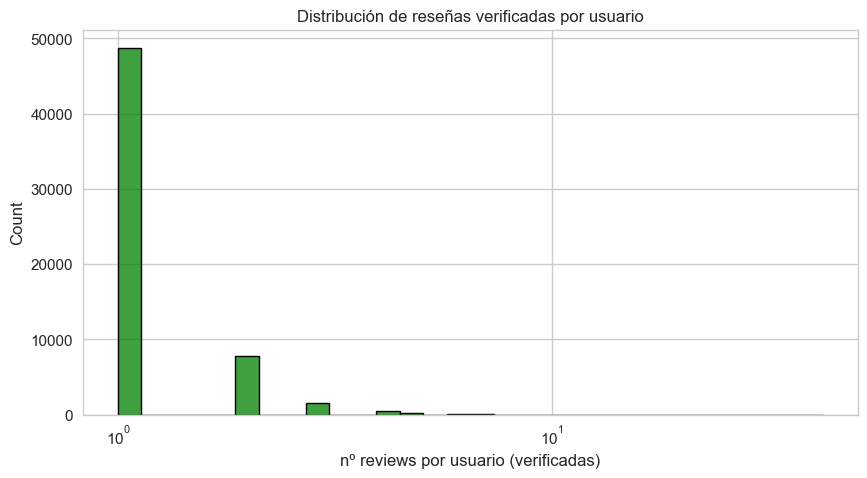

In [12]:
# Función para métricas de usuarios, incluyendo solo reseñas verificadas
def reviewer_metrics_verified(df, col="reviewerID", verified_col="verified"):
    # Total reseñas por usuario
    vc_all = df[col].value_counts()
    # Solo reseñas verificadas
    vc_verified = df[df[verified_col] == True][col].value_counts()
    
    def compute_metrics(vc):
        share1 = (vc == 1).mean() * 100
        share5 = (vc <= 5).mean() * 100

        # Cálculo Gini 
        sorted_vc = np.sort(vc.values)
        n = len(sorted_vc)
        cumvals = np.cumsum(sorted_vc)
        gini = (2 * np.sum((np.arange(1, n+1) * sorted_vc))) / (n * cumvals[-1]) - (n + 1) / n

        return share1, share5, gini, vc
    
    s1_all, s5_all, gini_all, vc_all = compute_metrics(vc_all)
    s1_ver, s5_ver, gini_ver, vc_ver = compute_metrics(vc_verified)
    
    return {
        "n_users_total": vc_all.size,
        "n_users_verified": vc_verified.size,
        "max_reviews_total": vc_all.max(),
        "max_reviews_verified": vc_verified.max(),
        "share1_total": s1_all,
        "share1_verified": s1_ver,
        "share≤5_total": s5_all,
        "share≤5_verified": s5_ver,
        "gini_total": gini_all,
        "gini_verified": gini_ver,
        "vc_total": vc_all,
        "vc_verified": vc_ver
    }

# Aplicación
m_verified = reviewer_metrics_verified(df)

# Graficar solo reseñas verificadas
plt.figure(figsize=(10,5))

# Número de bins más bajo para barras más gruesas
sns.histplot(
    m_verified["vc_verified"],
    bins=30,          
    log_scale=True,
    color='green',
    edgecolor='black'
)

plt.xlabel("nº reviews por usuario (verificadas)")
plt.ylabel("Count")
plt.title("Distribución de reseñas verificadas por usuario")
plt.show()


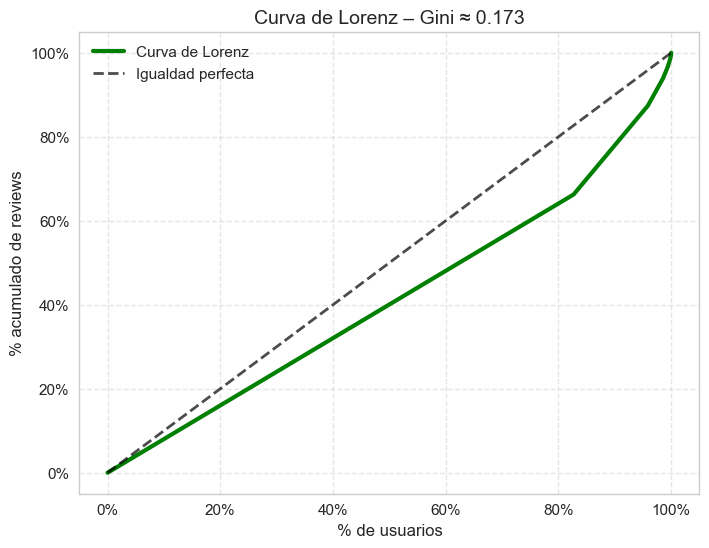

In [13]:
from matplotlib.ticker import PercentFormatter

# Extraemos los valores de reseñas verificadas por usuario
vc = m_verified["vc_verified"]

# Ordenar los usuarios de menor a mayor reseñas
sorted_vc = np.sort(vc.values)
n = len(sorted_vc)
cum_revs = np.cumsum(sorted_vc) / np.sum(sorted_vc)  # porcentaje acumulado de reseñas

# Gráfico de Lorenz ajustado
plt.figure(figsize=(8,6))
plt.plot(
    np.linspace(0,1,n), 
    cum_revs,            
    lw=3,
    color='green',
    label='Curva de Lorenz'
)
plt.plot([0,1],[0,1], ls="--", c="black", alpha=.7, lw=2, label='Igualdad perfecta')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.gca().xaxis.set_major_formatter(PercentFormatter(1))
plt.grid(True, linestyle='--', alpha=0.5)

plt.xlabel("% de usuarios", fontsize=12)
plt.ylabel("% acumulado de reviews", fontsize=12)
plt.title(f"Curva de Lorenz – Gini ≈ {m_verified['gini_verified']:.3f}", fontsize=14)
plt.legend()
plt.show()

**Larga cola de actividad**, la mayoría de los usuarios contribuyen de manera bastante uniforme; no existen “power-users” que dominen la cantidad de reseñas.  

Distribución equilibrada: el índice Gini ≈ 0.173 indica **baja desigualdad**, mostrando que la participación está repartida de manera equilibrada entre los usuarios.


In [16]:
# Analisis de Asin (Amazon Standard Identification Number)

print(df["asin"].value_counts())
print("\n" + "-"*40 + "\n")  
print(df["asin"].describe())
print("\n" + "-"*40 + "\n")
print(type(df["asin"][0]))

asin
B00PY4Q9OS    232
B00R8GUXPG    221
B000WGWQG8    220
B00Q0G2VXM    202
B00YSG2ZPA    198
             ... 
B000G6BLGA      1
B000Z27H7M      1
B0009J2ROE      1
B002FP1426      1
B00A8305MW      1
Name: count, Length: 27959, dtype: int64

----------------------------------------

count         100000
unique         27959
top       B00PY4Q9OS
freq             232
Name: asin, dtype: object

----------------------------------------

<class 'str'>


In [17]:
# Distribucción de reseñas por asin
counts_prod = df['asin'].value_counts()
share_1  = (counts_prod == 1).mean()         
share_5 = (counts_prod <= 5).mean()         


print(f"Share with only 1 review: {share_1:.2%}")
print(f"Share with 5 or less reviews: {share_5:.2%}")  

Share with only 1 review: 49.47%
Share with 5 or less reviews: 86.66%


In [18]:
# Análisis de Gini por asin

counts = counts_prod.values           
counts_sorted = np.sort(counts)       
n = len(counts_sorted)
cum_counts = np.cumsum(counts_sorted)

gini = (2 * (np.arange(1, n+1) * counts_sorted).sum()) / (n * counts_sorted.sum()) - (n + 1) / n
print(f'Gini index: {gini:.3f}')

Gini index: 0.580


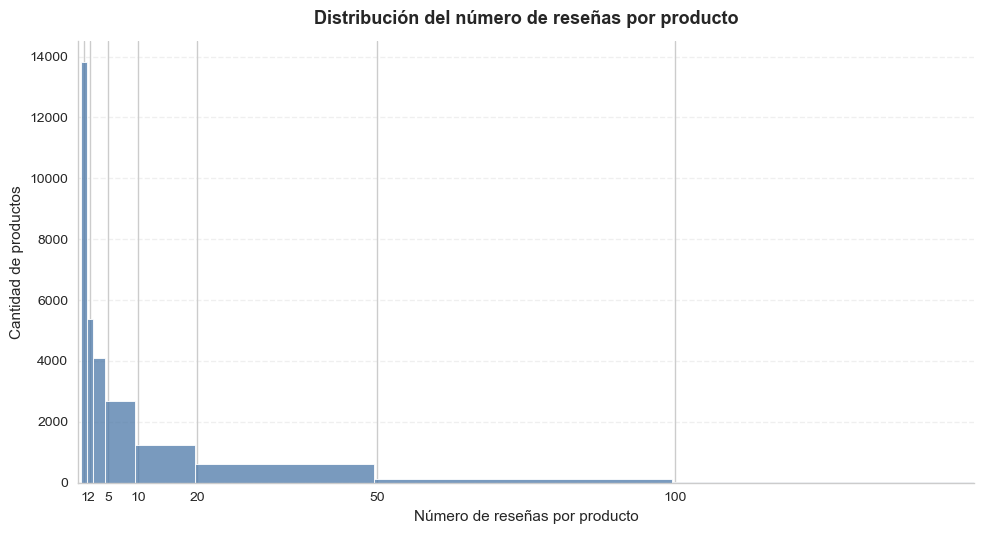

In [19]:
# Visualización

plt.figure(figsize=(10, 5.5))

# Histograma 
sns.histplot(
    data=counts_prod,
    bins=[0.5, 1.5, 2.5, 4.5, 9.5, 19.5, 49.5, 99.5, 199.5],
    color="#4c78a8",
    edgecolor="white",
    linewidth=0.6
)

# Etiquetas claras en escala normal (sin log)
plt.xticks(
    [1, 2, 5, 10, 20, 50, 100, 200],
    ['1', '2', '5', '10', '20', '50', '100', '200+'],
    fontsize=10
)

plt.yticks(fontsize=10)

plt.xlabel("Número de reseñas por producto", fontsize=11)
plt.ylabel("Cantidad de productos", fontsize=11)

plt.title("Distribución del número de reseñas por producto", 
          fontsize=13, fontweight='bold', pad=12)

# Limitar el rango visible para que se aprecie mejor la distribución
plt.xlim(0, 150)

# Estilo limpio
sns.despine()
plt.grid(True, axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

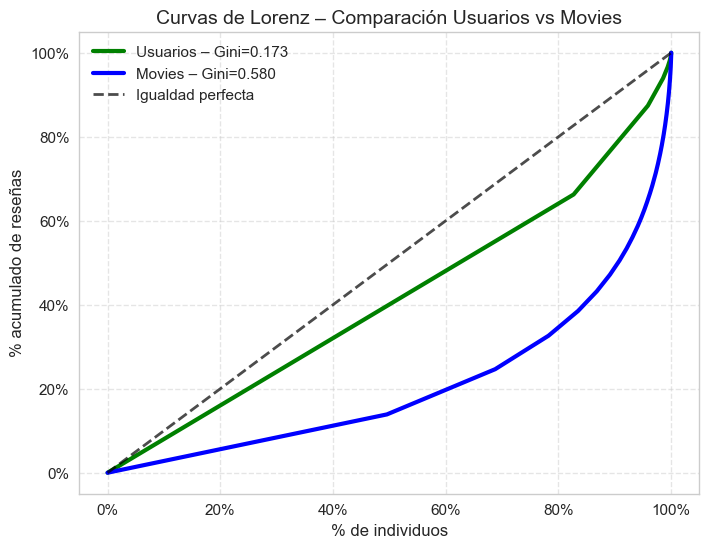

In [20]:
# Comparación de Ginis entre usuarion y movies (asin)

# Preparar datos para usuarios 
vc_users = m_verified["vc_verified"]  # reseñas por usuario
sorted_users = np.sort(vc_users.values)
cum_users = np.cumsum(sorted_users) / np.sum(sorted_users)
n_users = len(sorted_users)
gini_users = m_verified["gini_verified"]

# Preparar datos para movies 
vc_movies = df["asin"].value_counts()
sorted_movies = np.sort(vc_movies.values)
cum_movies = np.cumsum(sorted_movies) / np.sum(sorted_movies)
n_movies = len(sorted_movies)
# Gini de movies
gini_movies = (2 * (np.arange(1, n_movies+1) * sorted_movies).sum()) / (n_movies * sorted_movies.sum()) - (n_movies + 1) / n_movies

# Gráfico comparativo 
plt.figure(figsize=(8,6))

plt.plot(np.linspace(0,1,n_users), cum_users, lw=3, color='green', label=f'Usuarios – Gini={gini_users:.3f}')
plt.plot(np.linspace(0,1,n_movies), cum_movies, lw=3, color='blue', label=f'Movies – Gini={gini_movies:.3f}')
plt.plot([0,1],[0,1], ls="--", c="black", alpha=0.7, lw=2, label='Igualdad perfecta')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.gca().xaxis.set_major_formatter(PercentFormatter(1))
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel("% de individuos", fontsize=12)
plt.ylabel("% acumulado de reseñas", fontsize=12)
plt.title("Curvas de Lorenz – Comparación Usuarios vs Movies", fontsize=14)
plt.legend()
plt.show()

## Interpretación y implicaciones del gráfico de distribución de reseñas

- **Usuarios (verde, Gini ≈ 0.17):** La curva cercana a la diagonal indica que la **actividad de los usuarios está bastante equilibrada**, con la mayoría contribuyendo con un número similar de reseñas.  

- **Movies (azul, Gini ≈ 0.58):** La curva se aleja de la diagonal, mostrando que **unas pocas películas concentran muchas reseñas**, mientras que la mayoría recibe pocas, reflejando la típica **larga cola** en popularidad.

**Resumen:** Los usuarios presentan un comportamiento uniforme, mientras que las películas muestran una **distribución muy desigual**, explicando la diferencia en los índices de Gini.

**Implicación:**  
La alta desigualdad en la popularidad de las películas hace que el campo `movie` sea ideal para un **group split** al dividir Train/Test, evitando que la misma película aparezca en ambos conjuntos y previniendo la sobreestimación del modelo.  

Si se construyen features a nivel de película, será necesario aplicar técnicas que mitiguen la alta dispersión de popularidad (por ejemplo, **embeddings de películas** o **codificación basada en frecuencia**), ya que métricas simples como el promedio pueden ser inestables en películas con pocas reseñas.


### Sobre Variables `reviewerName` e `image`

La variable `reviewerName` corresponde al nombre público asociado al usuario que emite la reseña. No constituye un identificador único ni estable, ya que distintos usuarios pueden compartir el mismo nombre y un mismo usuario puede modificarlo a lo largo del tiempo. Dado que el análisis se basa en el identificador único `reviewerID`, esta variable no aporta información estructural adicional relevante.

Por su parte, la variable `image` contiene un enlace (URL) a una imagen asociada a lo que parece ser a una reseña o al producto, para este análisis no se realiza procesamiento de imágenes ni extracción de características visuales, por lo que esta variable no contribuye al modelado ni al análisis exploratorio principal.

En consecuencia, ambas variables se consideran no esenciales para los objetivos actuales del estudio y no se profundiza en su exploración.

In [21]:
# Análisis de reviewText
df["reviewText"].value_counts()

reviewText
great                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

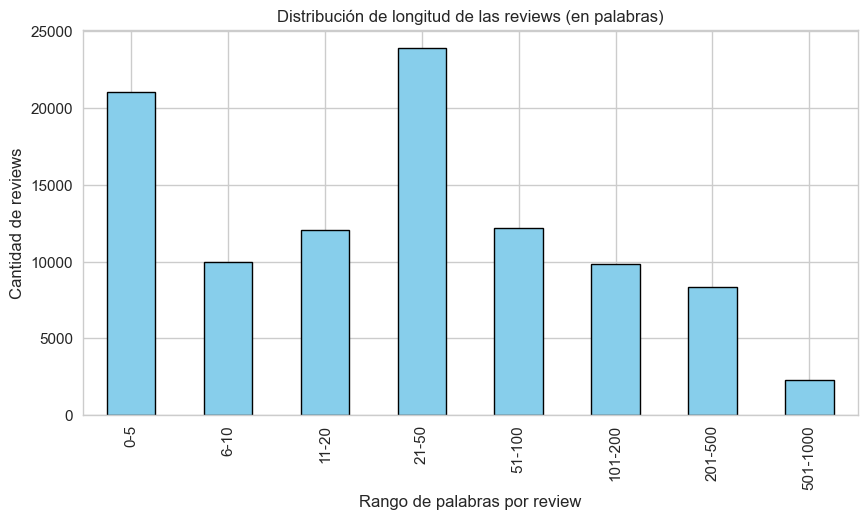

In [22]:
# Crear una columna temporal con el número de palabras por review
df['review_word_count'] = df['reviewText'].str.split().str.len()

# Definir los bins (rangos) de palabras
bins = [0, 5, 10, 20, 50, 100, 200, 500, 1000]  
labels = ['0-5','6-10','11-20','21-50','51-100','101-200','201-500','501-1000']

# Crear columna de categoría por rango de palabras
df['word_count_range'] = pd.cut(df['review_word_count'], bins=bins, labels=labels, right=True)

# Contar la cantidad de reviews por rango
range_counts = df['word_count_range'].value_counts().sort_index()

# Graficar
plt.figure(figsize=(10,5))
range_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel("Rango de palabras por review")
plt.ylabel("Cantidad de reviews")
plt.title("Distribución de longitud de las reviews (en palabras)")
plt.show()


La mayoría de las reseñas son **muy cortas**.

- El pico más alto está en **21–50 palabras** (24 000 reseñas), seguido de cerca por **0–5 palabras** (21 000).
- Más del 60–70% de todas las reseñas tienen **50 palabras o menos**.
- Las reseñas largas (>100 palabras) son claramente minoritarias y decrecen rápidamente.

**Conclusión rápida:** Predominan reseñas extremadamente breves o de longitud media-corta. Las opiniones detalladas y extensas son bastante raras en este conjunto de datos.

In [24]:
# Frecuencia de palabras en los textos

# Convertir todas las reseñas a minúsculas, unirlas y separar en palabras
all_words = ' '.join(df['reviewText'].dropna().astype(str).str.lower()).split()

# Filtrar stopwords en inglés
stop_words = set(stopwords.words('english'))
filtered_words = [w for w in all_words if w not in stop_words]

# Contar frecuencia de palabras filtradas
vocab_filtered = Counter(filtered_words)
top20 = vocab_filtered.most_common(20)

# Convertir a DataFrame para visualizar mejor
df_top20 = pd.DataFrame(top20, columns=['word', 'count'])
print(df_top20)

      word  count
0    movie  43622
1      one  32221
2    great  26898
3     good  26735
4     film  26569
5     like  25297
6    would  16535
7     love  16257
8   really  16240
9    story  14919
10     see  13621
11     get  13489
12       -  13233
13    even  12956
14   first  12948
15    much  12896
16  movie.  11989
17    time  11867
18     it.  11655
19    also  11243


In [25]:
# Función para limpiar cada texto
def clean_text(text):
    if not isinstance(text, str):
        return ""  # reemplaza NaN u otros tipos
    text = text.lower()  # minúsculas
    text = re.sub(r"[^a-z\s]", " ", text)  # solo letras y espacios
    text = re.sub(r"\s+", " ", text).strip()  # limpiar espacios extra
    return text

# Aplicar limpieza
df['review_clean'] = df['reviewText'].apply(clean_text)

# Vectorizador de bigramas
cv = CountVectorizer(ngram_range=(2,2), min_df=20, stop_words='english')
X = cv.fit_transform(df['review_clean'])

# Obtener los 30 bigramas más frecuentes
bigrams = sorted(zip(cv.get_feature_names_out(), X.sum(0).A1),
                 key=lambda x: -x[1])[:30]

# Mostrar
bigrams

[('great movie', 3758),
 ('good movie', 3486),
 ('blu ray', 3327),
 ('ve seen', 2135),
 ('special effects', 1820),
 ('cm cr', 1740),
 ('product link', 1740),
 ('ref cm', 1740),
 ('arp rvw', 1739),
 ('class link', 1739),
 ('cr arp', 1739),
 ('data hook', 1739),
 ('hook product', 1739),
 ('link linked', 1739),
 ('link normal', 1739),
 ('linked class', 1739),
 ('normal href', 1739),
 ('rvw txt', 1739),
 ('txt utf', 1739),
 ('story line', 1623),
 ('love movie', 1467),
 ('don know', 1362),
 ('year old', 1309),
 ('highly recommend', 1294),
 ('sci fi', 1291),
 ('movie great', 1269),
 ('pretty good', 1205),
 ('nbsp data', 1155),
 ('years ago', 1131),
 ('really good', 1072)]

Al generar los bigramas más frecuentes de las reseñas, aparecen tanto combinaciones de palabras significativas (por ejemplo, "great movie", "special effects", "love movie") como secuencias que parecen artefactos o metadatos del dataset (por ejemplo, "cm cr", "txt utf", "product link"). 

**Interpretación:**

- Los bigramas significativos reflejan expresiones reales de los usuarios sobre las películas y son útiles para análisis de sentimiento o temas comunes.
- Los artefactos corresponden a metadatos o restos de formato del dataset, que no aportan información sobre el contenido de la reseña.
- Esto es un **problema inherente al dataset**, no al método, y no afecta la validez de los análisis sobre los bigramas reales.

**Conclusión:**

Podemos continuar enfocándonos en los bigramas significativos para análisis de contenido, ignorando los artefactos generados por metadatos.


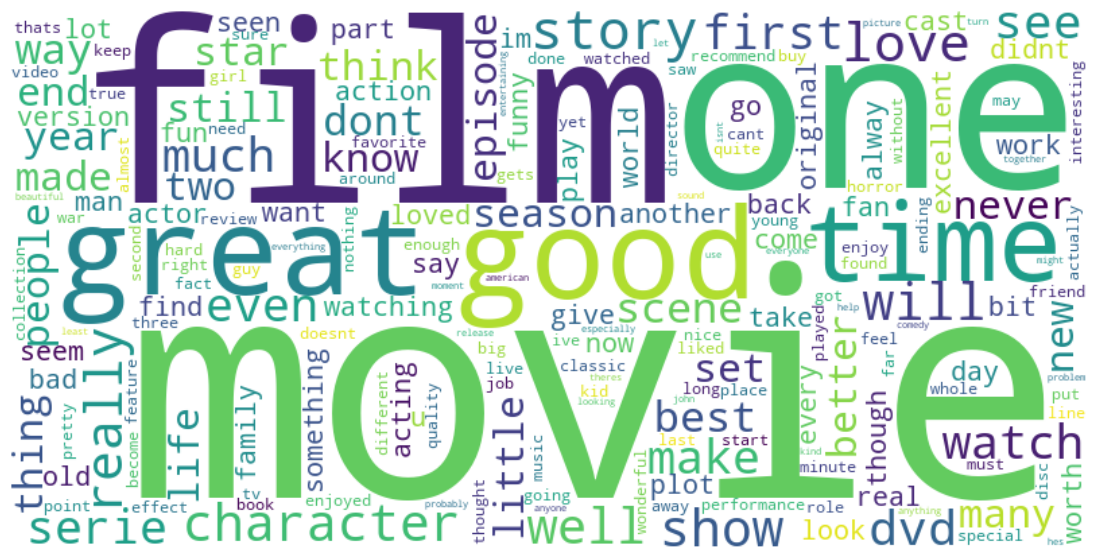

In [26]:
# Nube de palabras, una vista rápida de palabras que predominan la variable

# Filtrar nulos y pasar todo a string
texts = df['reviewText'].dropna().astype(str).str.lower()

# Limpiar texto: eliminar metadatos, símbolos y puntuación
def clean_text(text):
    text = re.sub(r'\S*cm_cr\S*', '', text)   # cm_cr...
    text = re.sub(r'\S*data\S*', '', text)    # data hook
    text = re.sub(r'\S*ref\S*', '', text)     # ref cm
    text = re.sub(r'\S*nbsp\S*', '', text)    # nbsp
    text = re.sub(r'[^\w\s]', '', text)       # quitar puntuación
    return text

cleaned_texts = texts.apply(clean_text)

# Generar nube de palabras
wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=None,
    collocations=False
)
wc.generate(' '.join(cleaned_texts))

# Mostrar nube 
plt.figure(figsize=(15,7))
plt.imshow(wc.to_image(), interpolation='bilinear')
plt.axis('off')
plt.show()


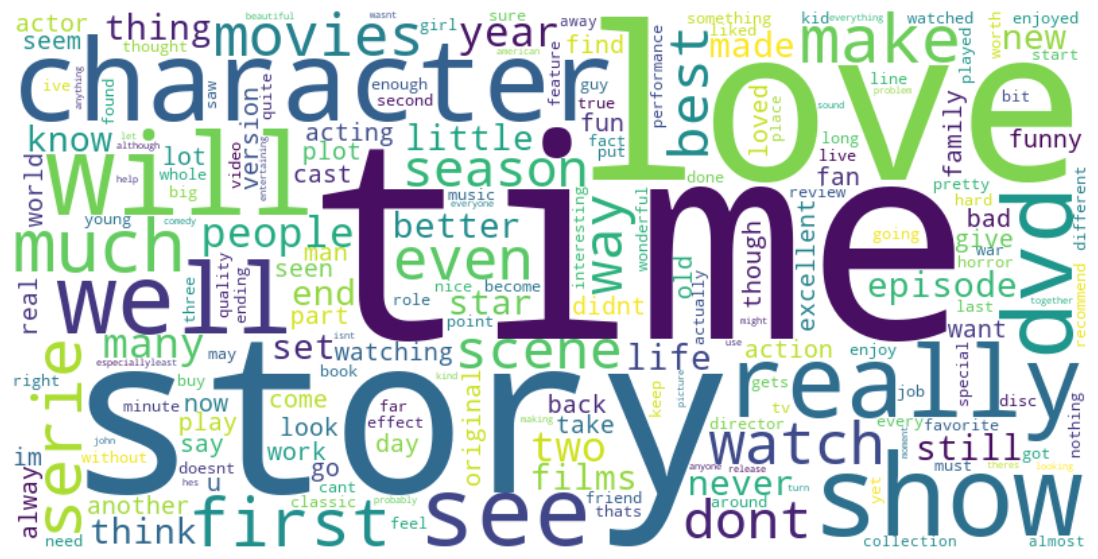

In [27]:
from wordcloud import WordCloud, STOPWORDS

# Nube personalizada con stopwords

# Filtrar nulos y convertir a string
texts = df['reviewText'].dropna().astype(str).str.lower()

# Limpiar texto (opcional, para eliminar metadatos)
def clean_text(text):
    text = re.sub(r'\S*cm_cr\S*', '', text)
    text = re.sub(r'\S*data\S*', '', text)
    text = re.sub(r'\S*ref\S*', '', text)
    text = re.sub(r'\S*nbsp\S*', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text

cleaned_texts = texts.apply(clean_text)

# Stopwords personalizadas
custom_stop = {'movie', 'film', 'one', 'good', 'great'}
all_stopwords = STOPWORDS.union(custom_stop)

# Generar nube
wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=all_stopwords,
    collocations=False
)
wc.generate(' '.join(cleaned_texts))

# Mostrar nube usando 
plt.figure(figsize=(15,7))
plt.imshow(wc.to_image(), interpolation='bilinear')
plt.axis('off')
plt.show()


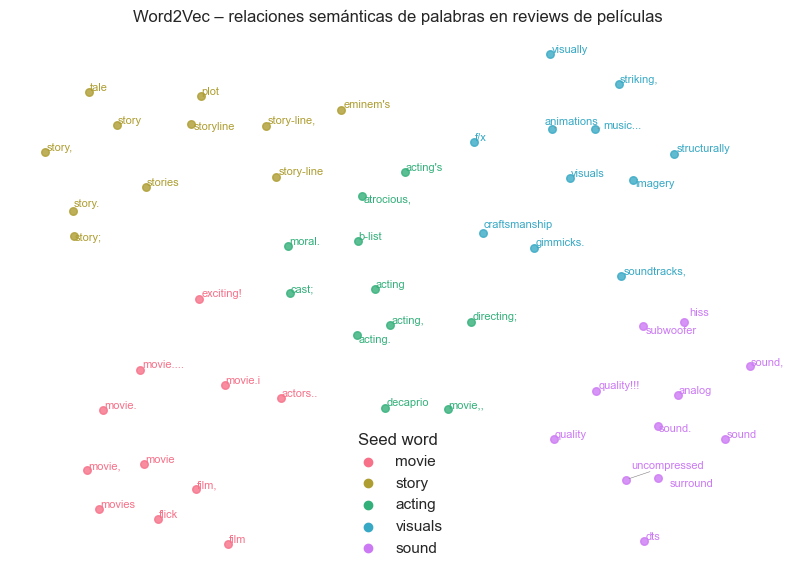

In [28]:
from gensim.models import Word2Vec
from umap import UMAP
from adjustText import adjust_text

# Agrupación semantica de palabras

#  Preparar el texto 
sw = set(stopwords.words('english'))

# Crear columna 'clean_text' ignorando NaN
df['clean_text'] = df['reviewText'].fillna('').str.lower()

#  Tokenización filtrada 
sentences = [[w for w in t.split() if w not in sw] for t in df['clean_text']]

# Entrenamiento de Word2Vec 
w2v = Word2Vec(
    sentences,
    vector_size=100, window=5, min_count=5, workers=4,
    epochs=10, sg=1, negative=10, seed=42
)

#  Palabras semilla relevantes para películas 
seed_words = ['movie', 'story', 'acting', 'visuals', 'sound']

words, embeds, cluster_id = [], [], []

for idx, seed in enumerate(seed_words):
    if seed not in w2v.wv:
        continue
    
    words.append(seed)
    embeds.append(w2v.wv[seed])
    cluster_id.append(idx)
    
    # Agregar 10 palabras más cercanas semánticamente
    for neigh, _ in w2v.wv.most_similar(seed, topn=10):
        words.append(neigh)
        embeds.append(w2v.wv[neigh])
        cluster_id.append(idx)

#  Reducción dimensional con UMAP 
umap2d = UMAP(n_components=2, random_state=42, min_dist=0.3).fit_transform(embeds)

# Visualización 
palette = sns.color_palette('husl', len(seed_words))
plt.figure(figsize=(10,7))
texts = []

for (x, y), w, c in zip(umap2d, words, cluster_id):
    color = palette[c]
    plt.scatter(x, y, s=30, color=color, alpha=0.8)
    texts.append(plt.text(x, y, w, fontsize=8, color=color))

# Evitar solapamientos
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.4))

# Leyenda
for i, seed in enumerate(seed_words):
    plt.scatter([], [], color=palette[i], label=seed)
plt.legend(title='Seed word')
plt.title('Word2Vec – relaciones semánticas de palabras en reviews de películas')
plt.axis('off')
plt.show()


In [29]:
# Verificación de valores anomalos

# Variable de longitud
df["tok_len_rew"] = (
    df["reviewText"]
        .fillna("")
        .str.split()
        .str.len()
)

# Métricas
nan_count = df["reviewText"].isna().sum()
cortos = (df["tok_len_rew"] < 3).sum()
largos = (df["tok_len_rew"] > 100).sum()
normales = (
    (df["tok_len_rew"] >= 3) &
    (df["tok_len_rew"] <= 100)
).sum()

print(
    "=========== Registro ===========\n"
    f"Total registros: {len(df)}\n"
    f"Valores NaN en reviewText: {nan_count}\n"
    "-------------------------------------------------\n"
    f"Reviews muy cortas (<3 tokens): {cortos}\n"
    f"Reviews normales (3–100 tokens): {normales}\n"
    f"Reviews largas (>100 tokens): {largos}\n"
    "================================================="
)


=========== Registro ===========
Total registros: 100000
Valores NaN en reviewText: 41
-------------------------------------------------
Reviews muy cortas (<3 tokens): 11669
Reviews normales (3–100 tokens): 67477
Reviews largas (>100 tokens): 20854


In [30]:
# Revisión de variable objetivo
df["overall"].value_counts()

overall
5    59302
4    19881
3    10076
1     5709
2     5032
Name: count, dtype: int64

<Axes: xlabel='overall', ylabel='Count'>

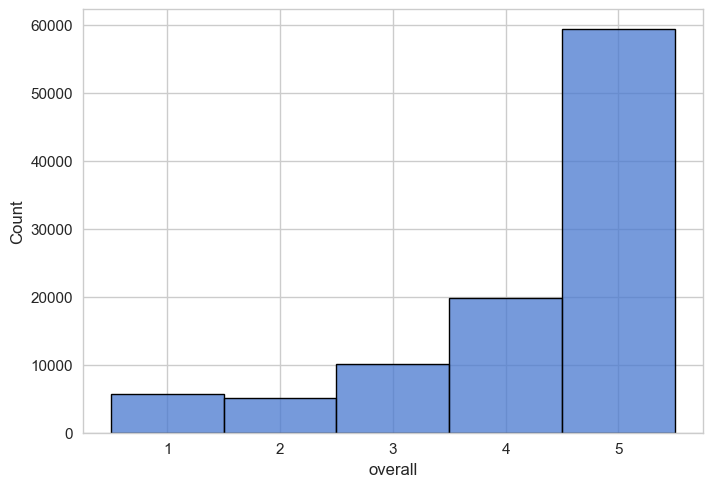

In [31]:
# histograma de la variable overall
sns.histplot(df['overall'], bins=10, discrete=True)

In [32]:
# Reviews positivas / negativas / neutral
df['sentiment_bin'] = np.select(
        [df.overall.isin([4,5]), df.overall.isin([1,2])],
        ['positive','negative'], default='neutral')
df.sentiment_bin.value_counts(normalize=True)

sentiment_bin
positive    0.79183
negative    0.10741
neutral     0.10076
Name: proportion, dtype: float64

<Axes: xlabel='sentiment_bin', ylabel='Count'>

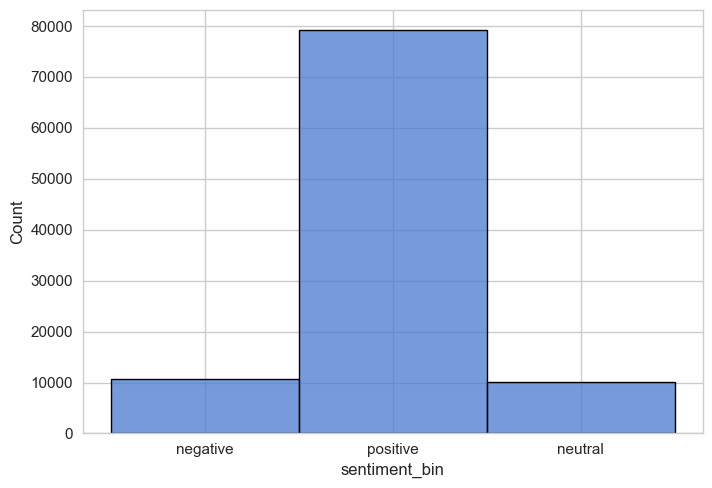

In [33]:
#Histograma de la variable sentiment_bin
sns.histplot(df['sentiment_bin'], discrete=True)

#### Distribución de Clases

Tras convertir las puntuaciones `overall` a la variable categórica `sentiment_bin`:

| Sentimiento | Proporción |
|-------------|------------|
| Positive    | 79.2 %     |
| Negative    | 10.7 %     |
| Neutral     | 10.1 %     |

#### Observaciones

- La distribución está **muy sesgada hacia reviews positivas** (casi 80 %).  
- Las reviews negativas y neutras representan juntas solo ~21 % del total.  
- Esto refleja que la mayoría de los usuarios otorgan puntuaciones altas en el dataset.

#### Implicaciones para Modelado

- Si se utiliza el target original (`positive`, `neutral`, `negative`) para entrenar un modelo, existe riesgo de **sesgo hacia la clase positiva**.  
- Para mitigar este desbalance y simplificar la predicción de sentimiento, se sugiere:

1. **Binarización del target**:
   - 1–3 ★ → `negative`
   - 4–5 ★ → `positive`
   - Neutral puede incluirse en `negative` o descartarse según objetivo.
2. **Oversampling o undersampling** en entrenamiento para balancear clases si se desea mantener las tres categorías.
3. Documentar siempre las proporciones para justificar decisiones de modelado.

#### Conclusión

- La mayoría de las reseñas son positivas → modelo tenderá a predecir `positive`.  
- Agrupar clases o aplicar técnicas de balanceo mejora la **robustez y generalización del modelo**.

In [34]:
# Revisión de variable summaty
df["summary"].value_counts()

summary
Five Stars                                                                 18090
Four Stars                                                                  4501
Three Stars                                                                 1970
One Star                                                                     910
Two Stars                                                                    778
                                                                           ...  
0 Stars If I Could... WILL NOT SUPPORT THIS!                                   1
Like a great story and don't mind fan service? Don't wait, just get it!        1
good for a rainy day                                                           1
Excellent adaptation from the Bible                                            1
The Best Christmas Movie Classic just got BETTER!                              1
Name: count, Length: 62685, dtype: int64

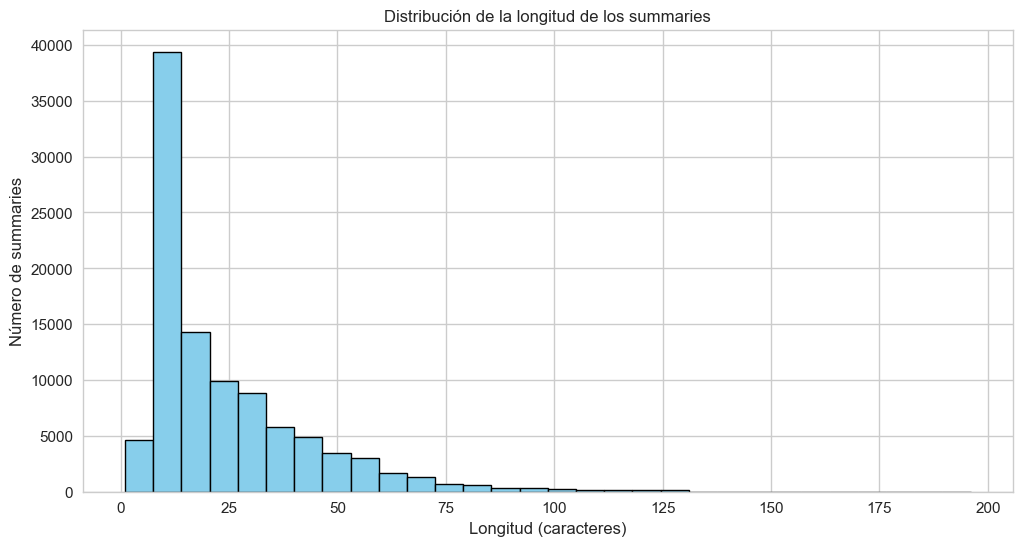

In [35]:
summary_lens = df["summary"].dropna().str.len()

plt.figure(figsize=(12,6))
plt.hist(summary_lens, bins=30, color='skyblue', edgecolor='black')
plt.title("Distribución de la longitud de los summaries")
plt.xlabel("Longitud (caracteres)")
plt.ylabel("Número de summaries")
plt.show()


In [36]:
df["summary"].describe()

count          99979
unique         62685
top       Five Stars
freq           18090
Name: summary, dtype: object

In [37]:
vacio = (df["summary"] == " ").sum()
print(f"Number of empty summaries: {vacio}")

Number of empty summaries: 0


### Conclusión de `summary`

- Funciona como una **mini-reseña rápida**, generalmente muy corta y repetitiva.  
- Coincide con la puntuación `overall` (“Five Stars”, “Four Stars”), indicando títulos casi automáticos.  
- Útil para capturar **sentimiento rápido**, pero conviene **limpiar o unificar títulos genéricos** para evitar sesgo.  
- Los títulos más largos y únicos pueden conservarse para **features semánticos adicionales**.


In [39]:
# Análisis de variable de tiempo

# Estadísticas descriptivas del tiempo de review
print("=== Estadísticas descriptivas de unixReviewTime ===")
print(df["unixReviewTime"].describe())
print("\n")

# Conteo de ocurrencias por timestamp
print("=== Conteo de ocurrencias por unixReviewTime ===")
print(df["unixReviewTime"].value_counts())
print("\n")

# Conversión a formato de fecha y primeras 10 filas
df['date'] = pd.to_datetime(df['unixReviewTime'], unit='s')
print("=== Primeras 10 fechas convertidas ===")
print(df['date'].head(10))

=== Estadísticas descriptivas de unixReviewTime ===
count    1.000000e+05
mean     1.385245e+09
std      1.148834e+08
min      8.954496e+08
25%      1.363478e+09
50%      1.419984e+09
75%      1.457741e+09
max      1.537920e+09
Name: unixReviewTime, dtype: float64


=== Conteo de ocurrencias por unixReviewTime ===
unixReviewTime
1424390400    249
1459209600    215
1455580800    197
1444176000    196
1461024000    194
             ... 
927331200       1
1281830400      1
1116979200      1
1036195200      1
1065484800      1
Name: count, Length: 6647, dtype: int64


=== Primeras 10 fechas convertidas ===
0   2012-10-09
1   2015-11-28
2   2016-05-30
3   2017-01-04
4   2015-04-12
5   2018-04-29
6   2015-07-05
7   2008-04-30
8   2016-02-15
9   2016-09-11
Name: date, dtype: datetime64[s]


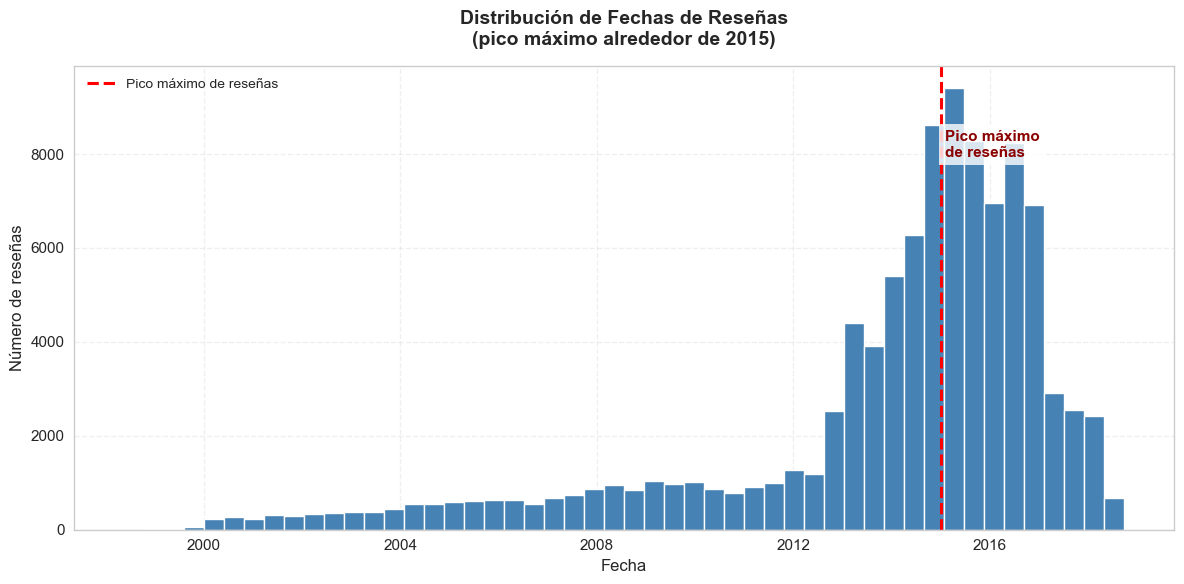

In [42]:
# Visualización de variable date

# Histograma 
ax = df['date'].hist(bins=50, figsize=(12, 6), color='#4682b4', edgecolor='white')

# Configuración visual
plt.title('Distribución de Fechas de Reseñas\n(pico máximo alrededor de 2015)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Número de reseñas', fontsize=12)

# Línea vertical en el pico
plt.axvline(x=pd.to_datetime('2015-01-01'), 
            color='red', linestyle='--', linewidth=2.2, 
            label='Pico máximo de reseñas')

# Anotación corta
plt.text(pd.to_datetime('2015-02-01'), 8200, 
         'Pico máximo\nde reseñas', 
         color='darkred', fontsize=11, fontweight='bold',
         ha='left', va='center',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()

# Mostrar
plt.show()

El histograma muestra la evolución temporal del número de reseñas dejadas por usuarios entre ≈2000 y 2018.

- Crecimiento lento y gradual hasta ~2012.
- **Aumento explosivo** a partir de 2013–2014.
- **Pico máximo** claramente visible alrededor de **2015** (más de 8.000 reseñas en el bin más alto).
- **Caída pronunciada y sostenida** después de 2015–2016.

**Resumen:** Fuerte boom de actividad de reseñas centrado en 2014–2015, seguido de un declive rápido.

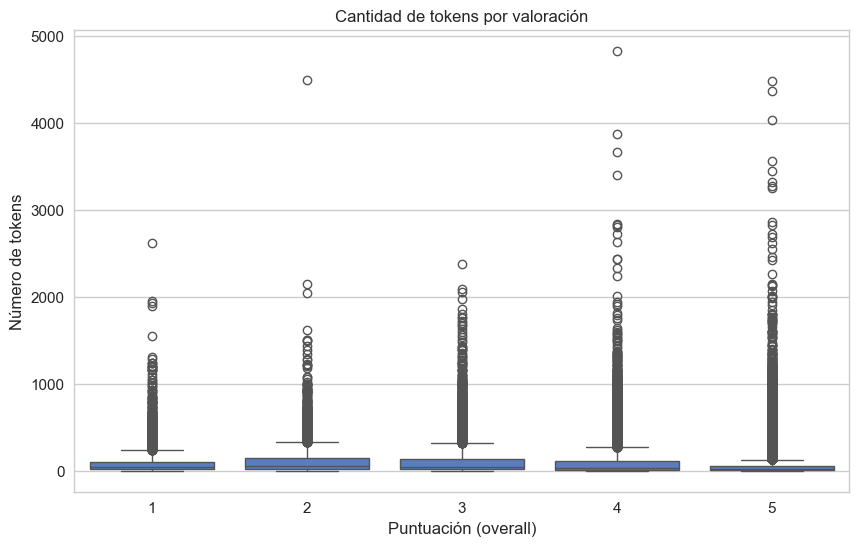

Correlación Spearman (longitud vs puntuación): -0.193


In [44]:
# ¿Los textos cortos son mejor valorados que los textos largos?

# Crear columna de longitud de review en tokens
df['tok_len_rew'] = df['reviewText'].fillna("").str.split().str.len()

# Boxplot: tokens por valoración
plt.figure(figsize=(10,6))
sns.boxplot(x='overall', y='tok_len_rew', data=df)
plt.title('Cantidad de tokens por valoración')
plt.xlabel('Puntuación (overall)')
plt.ylabel('Número de tokens')
plt.show()

# Correlación 
correlation = df[['tok_len_rew', 'overall']].corr(method='spearman').iloc[0,1]
print(f"Correlación Spearman (longitud vs puntuación): {correlation:.3f}")

## Correlación longitud vs puntuación

En este dataset existe una **correlación negativa débil** (Spearman ≈ -0.19) entre la longitud del texto y la puntuación: los textos muy breves (0–500 tokens) suelen recibir **valoraciones altas (4–5)**, mientras que los más largos tienden ligeramente a obtener **valoraciones bajas (1–2)**.